⏳ Đang chuẩn bị dữ liệu và Feature Engineering...
✅ Đang phân lớp cho 5 nhãn: ['Partly Cloudy', 'Mostly Cloudy', 'Overcast', 'Clear', 'Foggy']
⏳ Đang huấn luyện Random Forest...
✅ Huấn luyện xong! F1-Macro Score: 0.5419

BÁO CÁO PHÂN LỚP (CLASSIFICATION REPORT)
               precision    recall  f1-score   support

        Clear       0.40      0.52      0.45      1988
        Foggy       0.57      0.82      0.67      1431
Mostly Cloudy       0.53      0.43      0.48      5633
     Overcast       0.50      0.58      0.54      3286
Partly Cloudy       0.61      0.54      0.57      6307

     accuracy                           0.53     18645
    macro avg       0.52      0.58      0.54     18645
 weighted avg       0.54      0.53      0.53     18645

⏳ Đang vẽ Confusion Matrix để phân tích lỗi...


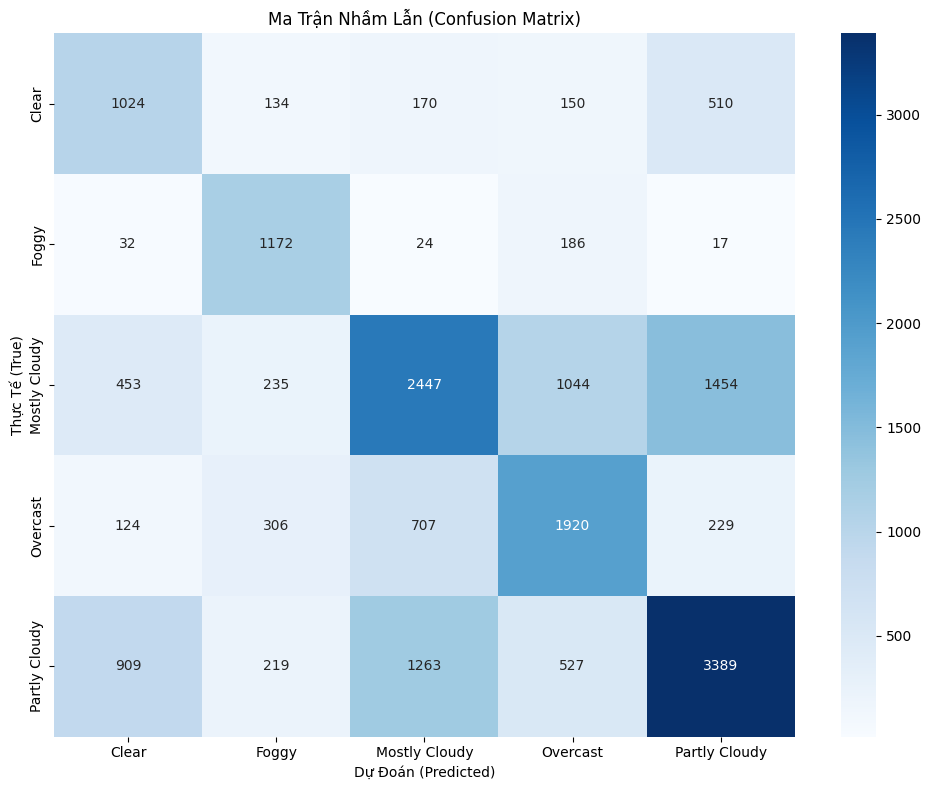

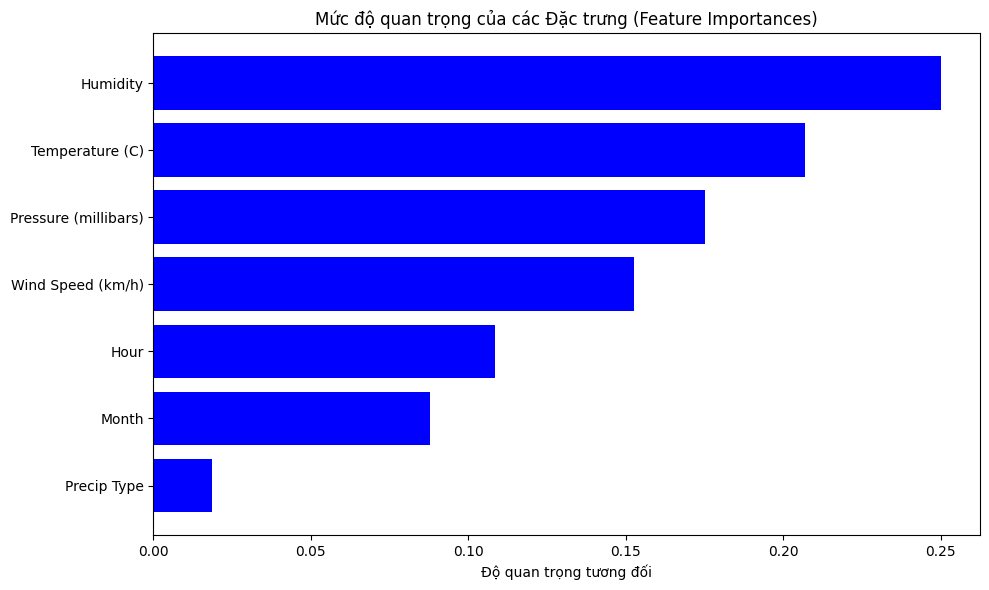

In [2]:
import os
import sys
import pandas as pd

if os.getcwd().endswith('notebooks'):
    os.chdir('..')
sys.path.append(os.getcwd())

from src.classification_models import WeatherClassification
import yaml

# 1. Đọc dữ liệu
with open("configs/params.yaml", "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)
df_clean = pd.read_csv(config['data']['processed_path'])

# 2. Khởi tạo Pipeline Phân lớp
clf_model = WeatherClassification()

# 3. Chuẩn bị dữ liệu
(X_train, X_test, y_train, y_test), target_names = clf_model.prepare_data(df_clean)

# 4. Huấn luyện và Đánh giá (F1-Macro)
y_pred = clf_model.train_and_evaluate(X_train, X_test, y_train, y_test, target_names)

# 5. Phân tích lỗi bằng Confusion Matrix
clf_model.plot_confusion_matrix(y_test, y_pred, target_names)

# 6. Xem đặc trưng nào quyết định thời tiết
clf_model.plot_feature_importance(X_train.columns)

⏳ Đang huấn luyện và so sánh các mô hình...
✅ Decision Tree (Baseline 1) - F1-Macro: 0.4602
✅ Random Forest (Baseline 2) - F1-Macro: 0.5419
✅ XGBoost (Cải tiến) - F1-Macro: 0.4947


d:\khaiphadulieu\Du_Bao_Thoi_Tiet\src\classification_models.py:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(results.values()), y=list(results.keys()), palette='magma')


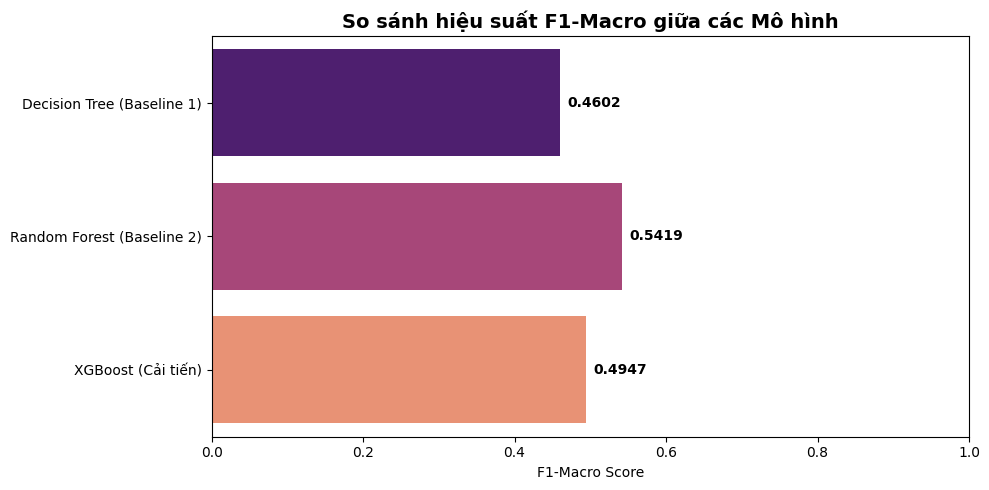

In [3]:
# Gọi hàm so sánh 3 mô hình
results = clf_model.compare_models(X_train, X_test, y_train, y_test)